# Import Libraries

In [332]:
import pandas as pd # for data manipulation and analysis
import numpy as np  # for numerical computation


# Load Datasets

In [333]:
matches = pd.read_csv("/content/matches.csv")
deliveries = pd.read_csv("/content/deliveries.csv")

print("Dataset loaded")

Dataset loaded


## Dataset Overview (Matches)

In [334]:
print(matches.head(3))
print(matches.shape)

   id  season       city        date                team1  \
0   1    2017  Hyderabad  2017-04-05  Sunrisers Hyderabad   
1   2    2017       Pune  2017-04-06       Mumbai Indians   
2   3    2017     Rajkot  2017-04-07        Gujarat Lions   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   

   result  dl_applied                  winner  win_by_runs  win_by_wickets  \
0  normal           0     Sunrisers Hyderabad           35               0   
1  normal           0  Rising Pune Supergiant            0               7   
2  normal           0   Kolkata Knight Riders            0              10   

  player_of_match                                      venue         umpire1  \
0    Yuvraj Singh  Rajiv Gandhi International Stadium

In [335]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']


In [336]:
print(matches.isnull().sum())

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64


## Dataset Overview (Deliveries)

In [337]:
print(deliveries.head(3))
print(deliveries.shape)

   match_id  inning         batting_team                 bowling_team  over  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   

   ball    batsman non_striker    bowler  is_super_over  ...  bye_runs  \
0     1  DA Warner    S Dhawan  TS Mills              0  ...         0   
1     2  DA Warner    S Dhawan  TS Mills              0  ...         0   
2     3  DA Warner    S Dhawan  TS Mills              0  ...         0   

   legbye_runs  noball_runs  penalty_runs  batsman_runs  extra_runs  \
0            0            0             0             0           0   
1            0            0             0             0           0   
2            0            0             0             4           0   

   total_runs  player_dismissed dismissal_kind fielder  
0           0               NaN            N

In [338]:
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']


In [339]:
print(deliveries.isnull().sum())

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64


# Clean matches

In [340]:
matches_clean = matches.drop(columns=['umpire3', 'player_of_match', 'umpire1', 'umpire2']) # drop unnecessary column

In [341]:
matches_clean = matches_clean.dropna(subset=['winner'])  # drop no-result matches

In [342]:
matches_clean['city'] = matches_clean['city'].fillna(matches_clean['city'].mode()[0])

In [343]:
print("Matches after cleaning:", matches_clean.shape)
print("Null check:\n", matches_clean.isnull().sum())

Matches after cleaning: (633, 14)
Null check:
 id                0
season            0
city              0
date              0
team1             0
team2             0
toss_winner       0
toss_decision     0
result            0
dl_applied        0
winner            0
win_by_runs       0
win_by_wickets    0
venue             0
dtype: int64


# Clean deliveries

In [344]:
deliveries_clean = deliveries[deliveries['is_super_over'] == 0]

In [345]:
print("Deliveries after removing super overs:", deliveries_clean.shape)

Deliveries after removing super overs: (150379, 21)


In [346]:
print("Null check:\n", deliveries_clean.isnull().sum())

Null check:
 match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    142955
dismissal_kind      142955
fielder             145018
dtype: int64


### Feature Engineering: Converting Ball-Level Data into Over-Level Statistics

In [347]:
over_data = deliveries_clean.groupby(['match_id', 'inning', 'over']).agg(
    runs_in_over      = ('total_runs', 'sum'),
    wickets_in_over   = ('player_dismissed', lambda x: x.notna().sum()),
    extras_in_over    = ('extra_runs', 'sum'),
    fours_in_over     = ('batsman_runs', lambda x: (x == 4).sum()),
    sixes_in_over     = ('batsman_runs', lambda x: (x == 6).sum()),
    dots_in_over      = ('total_runs', lambda x: (x == 0).sum()),
    batting_team      = ('batting_team', 'first'),
    bowling_team      = ('bowling_team', 'first')
).reset_index()


print("Over level shape:", over_data.shape)

Over level shape: (24374, 11)


In [348]:
over_data.head(10)

,match_id,inning,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,dots_in_over,batting_team,bowling_team
0,1,1,1,7,0,3,1,0,4,Sunrisers Hyderabad,Royal Challengers Bangalore
1,1,1,2,16,1,1,2,1,2,Sunrisers Hyderabad,Royal Challengers Bangalore
2,1,1,3,6,0,0,0,0,2,Sunrisers Hyderabad,Royal Challengers Bangalore
3,1,1,4,4,0,0,0,0,2,Sunrisers Hyderabad,Royal Challengers Bangalore
4,1,1,5,9,0,0,1,0,1,Sunrisers Hyderabad,Royal Challengers Bangalore
5,1,1,6,17,0,0,4,0,1,Sunrisers Hyderabad,Royal Challengers Bangalore
6,1,1,7,5,0,0,0,0,1,Sunrisers Hyderabad,Royal Challengers Bangalore
7,1,1,8,11,0,0,0,1,0,Sunrisers Hyderabad,Royal Challengers Bangalore
8,1,1,9,9,0,0,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
9,1,1,10,4,0,0,0,0,2,Sunrisers Hyderabad,Royal Challengers Bangalore


### Feature Engineering: Creating Derived Match Features for Over-Level Analysis

In [349]:
over_data = over_data.sort_values(['match_id', 'inning', 'over']).reset_index(drop=True)

over_data['total_runs']    = over_data.groupby(['match_id', 'inning'])['runs_in_over'].cumsum()
over_data['total_wickets'] = over_data.groupby(['match_id', 'inning'])['wickets_in_over'].cumsum()
over_data['total_extras']  = over_data.groupby(['match_id', 'inning'])['extras_in_over'].cumsum()
over_data['total_fours']   = over_data.groupby(['match_id', 'inning'])['fours_in_over'].cumsum()
over_data['total_sixes']   = over_data.groupby(['match_id', 'inning'])['sixes_in_over'].cumsum()
over_data['total_dots']    = over_data.groupby(['match_id', 'inning'])['dots_in_over'].cumsum()


In [350]:
print(over_data.shape)

(24374, 17)


In [351]:

over_data.head(10)

,match_id,inning,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,dots_in_over,batting_team,bowling_team,total_runs,total_wickets,total_extras,total_fours,total_sixes,total_dots
0,1,1,1,7,0,3,1,0,4,Sunrisers Hyderabad,Royal Challengers Bangalore,7,0,3,1,0,4
1,1,1,2,16,1,1,2,1,2,Sunrisers Hyderabad,Royal Challengers Bangalore,23,1,4,3,1,6
2,1,1,3,6,0,0,0,0,2,Sunrisers Hyderabad,Royal Challengers Bangalore,29,1,4,3,1,8
3,1,1,4,4,0,0,0,0,2,Sunrisers Hyderabad,Royal Challengers Bangalore,33,1,4,3,1,10
4,1,1,5,9,0,0,1,0,1,Sunrisers Hyderabad,Royal Challengers Bangalore,42,1,4,4,1,11
5,1,1,6,17,0,0,4,0,1,Sunrisers Hyderabad,Royal Challengers Bangalore,59,1,4,8,1,12
6,1,1,7,5,0,0,0,0,1,Sunrisers Hyderabad,Royal Challengers Bangalore,64,1,4,8,1,13
7,1,1,8,11,0,0,0,1,0,Sunrisers Hyderabad,Royal Challengers Bangalore,75,1,4,8,2,13
8,1,1,9,9,0,0,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore,84,1,4,8,2,13
9,1,1,10,4,0,0,0,0,2,Sunrisers Hyderabad,Royal Challengers Bangalore,88,1,4,8,2,15


### Merging Over-Level Data with Match-Level Information

In [352]:
# Select only the important match-level columns
match_cols = [
    'id', 'team1', 'team2', 'toss_winner', 'toss_decision',
    'winner', 'venue', 'city', 'season', 'dl_applied'
]

# Merge over-level data with match-level information
df = over_data.merge(
    matches_clean[match_cols],
    left_on='match_id',
    right_on='id',
    how='left'
)

# Remove duplicate column after merge
df.drop(columns='id', inplace=True)

# Check the result
print("Final dataset shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())


Final dataset shape: (24374, 26)

Missing values per column:
 match_id            0
inning              0
over                0
runs_in_over        0
wickets_in_over     0
extras_in_over      0
fours_in_over       0
sixes_in_over       0
dots_in_over        0
batting_team        0
bowling_team        0
total_runs          0
total_wickets       0
total_extras        0
total_fours         0
total_sixes         0
total_dots          0
team1              53
team2              53
toss_winner        53
toss_decision      53
winner             53
venue              53
city               53
season             53
dl_applied         53
dtype: int64


In [353]:
print("\nSample data:\n", df.head(3))


Sample data:
    match_id  inning  over  runs_in_over  wickets_in_over  extras_in_over  \
0         1       1     1             7                0               3   
1         1       1     2            16                1               1   
2         1       1     3             6                0               0   

   fours_in_over  sixes_in_over  dots_in_over         batting_team  ...  \
0              1              0             4  Sunrisers Hyderabad  ...   
1              2              1             2  Sunrisers Hyderabad  ...   
2              0              0             2  Sunrisers Hyderabad  ...   

  total_dots                team1                        team2  \
0          4  Sunrisers Hyderabad  Royal Challengers Bangalore   
1          6  Sunrisers Hyderabad  Royal Challengers Bangalore   
2          8  Sunrisers Hyderabad  Royal Challengers Bangalore   

                   toss_winner  toss_decision               winner  \
0  Royal Challengers Bangalore          fiel

# Cleaning merged data

In [354]:
# Drop rows where match info didn't merge (abandoned matches)
df = df.dropna(subset=['winner', 'team1', 'team2'])
print("After dropping unmatched:", df.shape)

After dropping unmatched: (24321, 26)


In [355]:
print(df.isnull().sum())  # Null check

match_id           0
inning             0
over               0
runs_in_over       0
wickets_in_over    0
extras_in_over     0
fours_in_over      0
sixes_in_over      0
dots_in_over       0
batting_team       0
bowling_team       0
total_runs         0
total_wickets      0
total_extras       0
total_fours        0
total_sixes        0
total_dots         0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
venue              0
city               0
season             0
dl_applied         0
dtype: int64


In [356]:
# Get final score of 1st innings per match
inning1_scores = df[df['inning'] == 1].groupby('match_id')['total_runs'].max().reset_index()

inning1_scores.columns = ['match_id', 'inning1_total']

# Merge it back
df = df.merge(inning1_scores, on='match_id', how='left')

In [357]:
df = df[df['inning'] == 2]

In [358]:
df.head(10)

,match_id,inning,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,dots_in_over,batting_team,...,team1,team2,toss_winner,toss_decision,winner,venue,city,season,dl_applied,inning1_total
20,1,2,1,11,0,0,2,0,2,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
21,1,2,2,1,0,0,0,0,5,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
22,1,2,3,16,0,0,2,1,1,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
23,1,2,4,15,0,1,1,1,1,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
24,1,2,5,5,0,1,1,0,5,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
25,1,2,6,6,1,0,1,0,4,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
26,1,2,7,7,1,0,0,1,4,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
27,1,2,8,13,0,0,2,0,0,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
28,1,2,9,11,0,1,0,1,1,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207
29,1,2,10,13,0,1,2,0,1,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207


# Creating target variable

In [359]:
df['target'] = (df['batting_team'] == df['winner']).astype(int)

In [360]:
df.head()

,match_id,inning,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,dots_in_over,batting_team,...,team2,toss_winner,toss_decision,winner,venue,city,season,dl_applied,inning1_total,target
20,1,2,1,11,0,0,2,0,2,Royal Challengers Bangalore,...,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207,0
21,1,2,2,1,0,0,0,0,5,Royal Challengers Bangalore,...,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207,0
22,1,2,3,16,0,0,2,1,1,Royal Challengers Bangalore,...,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207,0
23,1,2,4,15,0,1,1,1,1,Royal Challengers Bangalore,...,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207,0
24,1,2,5,5,0,1,1,0,5,Royal Challengers Bangalore,...,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017.0,0.0,207,0


# Class imbalance check

In [361]:
print(df['target'].value_counts())

target
1    6263
0    5530
Name: count, dtype: int64


# Feature engineering 2nd Innings

In [362]:
# Runs needed (based on 1st innings total)
df['runs_needed'] = df['inning1_total'] + 1 - df['total_runs']

# Balls left (assuming T20: 20 overs = 120 balls)
df['balls_left'] = (20 * 6) - (df['over'] * 6)

# Wickets remaining
df['wickets_remaining'] = 10 - df['total_wickets']

# Current run rate
df['current_run_rate'] = df['total_runs'] / (df['over'] + 1)

# Required run rate
df['required_run_rate'] = np.where(
    df['balls_left'] > 0,
    df['runs_needed'] / (df['balls_left'] / 6),
    0
)

# Run rate difference
df['rr_diff'] = df['current_run_rate'] - df['required_run_rate']

# Match phase (optional but useful)
df['phase'] = pd.cut(
    df['over'],
    bins=[0, 6, 15, 20],
    labels=[0, 1, 2]
).astype(int)

# Final feature set
features = [
    'runs_needed',
    'balls_left',
    'wickets_remaining',
    'current_run_rate',
    'required_run_rate',
    'rr_diff',
    'phase'
]

X = df[features]

In [363]:
df.head(10)

,match_id,inning,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,dots_in_over,batting_team,...,dl_applied,inning1_total,target,runs_needed,balls_left,wickets_remaining,current_run_rate,required_run_rate,rr_diff,phase
20,1,2,1,11,0,0,2,0,2,Royal Challengers Bangalore,...,0.0,207,0,197,114,10,5.500000,10.368421,-4.868421,0
21,1,2,2,1,0,0,0,0,5,Royal Challengers Bangalore,...,0.0,207,0,196,108,10,4.000000,10.888889,-6.888889,0
22,1,2,3,16,0,0,2,1,1,Royal Challengers Bangalore,...,0.0,207,0,180,102,10,7.000000,10.588235,-3.588235,0
23,1,2,4,15,0,1,1,1,1,Royal Challengers Bangalore,...,0.0,207,0,165,96,10,8.600000,10.312500,-1.712500,0
24,1,2,5,5,0,1,1,0,5,Royal Challengers Bangalore,...,0.0,207,0,160,90,10,8.000000,10.666667,-2.666667,0
25,1,2,6,6,1,0,1,0,4,Royal Challengers Bangalore,...,0.0,207,0,154,84,9,7.714286,11.000000,-3.285714,0
26,1,2,7,7,1,0,0,1,4,Royal Challengers Bangalore,...,0.0,207,0,147,78,8,7.625000,11.307692,-3.682692,1
27,1,2,8,13,0,0,2,0,0,Royal Challengers Bangalore,...,0.0,207,0,134,72,8,8.222222,11.166667,-2.944444,1
28,1,2,9,11,0,1,0,1,1,Royal Challengers Bangalore,...,0.0,207,0,123,66,8,8.500000,11.181818,-2.681818,1
29,1,2,10,13,0,1,2,0,1,Royal Challengers Bangalore,...,0.0,207,0,110,60,8,8.909091,11.000000,-2.090909,1


# Define Features and Target

In [364]:
X = df.drop(columns=['target'])
y = df['target']

# Group based split

In [365]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=df['match_id']))

# Create train and test sets

In [366]:
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9379, 34)
Test shape: (2414, 34)


# Dropping Unnecessary Features

In [367]:
cols_to_drop = ['city', 'venue', 'toss_winner', 'team1', 'team2','winner','toss_decision', 'match_id']

X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

# Categorical Feature Encoding (One-hot encoding )

In [368]:
categorical_columns = ['batting_team', 'bowling_team']

# one hot encoding - fitting on training data

X_train = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [369]:
X_train.head()

,inning,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,dots_in_over,total_runs,total_wickets,...,bowling_team_Kings XI Punjab,bowling_team_Kochi Tuskers Kerala,bowling_team_Kolkata Knight Riders,bowling_team_Mumbai Indians,bowling_team_Pune Warriors,bowling_team_Rajasthan Royals,bowling_team_Rising Pune Supergiant,bowling_team_Rising Pune Supergiants,bowling_team_Royal Challengers Bangalore,bowling_team_Sunrisers Hyderabad
20,2,1,11,0,0,2,0,2,11,0,...,False,False,False,False,False,False,False,False,False,True
21,2,2,1,0,0,0,0,5,12,0,...,False,False,False,False,False,False,False,False,False,True
22,2,3,16,0,0,2,1,1,28,0,...,False,False,False,False,False,False,False,False,False,True
23,2,4,15,0,1,1,1,1,43,0,...,False,False,False,False,False,False,False,False,False,True
24,2,5,5,0,1,1,0,5,48,0,...,False,False,False,False,False,False,False,False,False,True


In [370]:
y_train.head()

,target
20,0
21,0
22,0
23,0
24,0


# Training Model

In [371]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [372]:
y_train_pred = model.predict(X_train)

# Training report

In [373]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4378
           1       1.00      1.00      1.00      5001

    accuracy                           1.00      9379
   macro avg       1.00      1.00      1.00      9379
weighted avg       1.00      1.00      1.00      9379



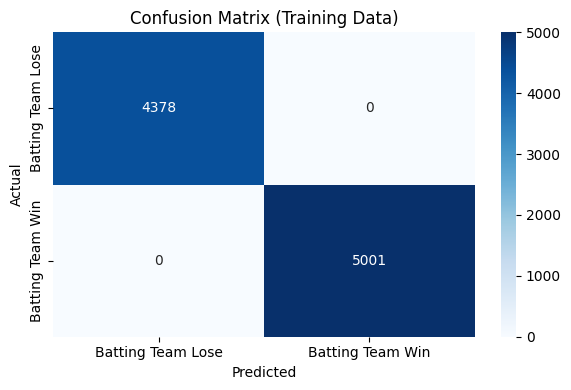

In [374]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Batting Team Lose', 'Batting Team Win'],
            yticklabels=['Batting Team Lose', 'Batting Team Win'])

plt.title('Confusion Matrix (Training Data)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Model Testing and Report

In [375]:
y_pred = model.predict(X_test)

In [376]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7423363711681856
              precision    recall  f1-score   support

           0       0.70      0.79      0.75      1152
           1       0.79      0.69      0.74      1262

    accuracy                           0.74      2414
   macro avg       0.75      0.74      0.74      2414
weighted avg       0.75      0.74      0.74      2414



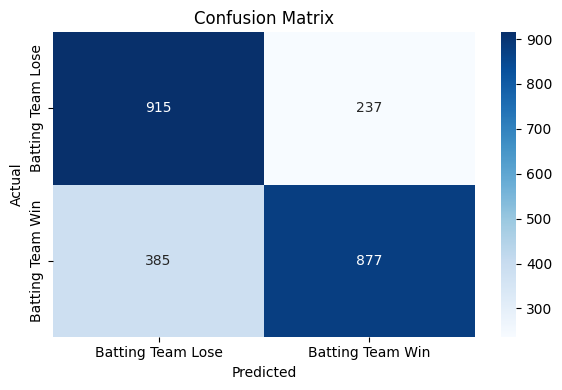

In [377]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Batting Team Lose', 'Batting Team Win'],
            yticklabels=['Batting Team Lose', 'Batting Team Win'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

***With this we can clearly identify the model is overfitting***

> Add blockquote



# Training model again to overcome overfitting

In [378]:
# updated parameters

rf = RandomForestClassifier(
    n_estimators=300,          # increased trees for better performance
    max_depth=10,              # limit tree depth
    min_samples_split=10,      # increase regularization
    min_samples_leaf=8,        # increase regularization
    max_features='sqrt',       # better generalization
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, min_samples_leaf=8, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [379]:
# Predictions on TRAIN data
y_train_pred = rf.predict(X_train)


print("Training Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))

print("Report:")
print(classification_report(y_train, y_train_pred, target_names=['Team2 Won', 'Team1 Won']))

Training Accuracy: 0.8762
Report:
              precision    recall  f1-score   support

   Team2 Won       0.87      0.86      0.87      4378
   Team1 Won       0.88      0.89      0.88      5001

    accuracy                           0.88      9379
   macro avg       0.88      0.88      0.88      9379
weighted avg       0.88      0.88      0.88      9379



Accuracy: 0.7432
Report:
              precision    recall  f1-score   support

   Team2 Won       0.71      0.78      0.74      1152
   Team1 Won       0.78      0.71      0.74      1262

    accuracy                           0.74      2414
   macro avg       0.75      0.74      0.74      2414
weighted avg       0.75      0.74      0.74      2414



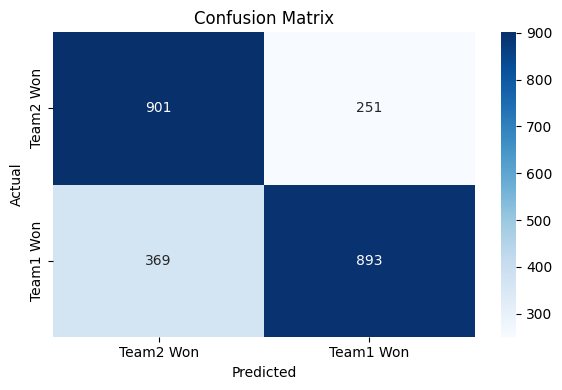

Important Features:
required_run_rate    0.224577
rr_diff              0.209861
inning1_total        0.121336
total_wickets        0.068911
wickets_remaining    0.064466
runs_needed          0.059179
current_run_rate     0.034405
season               0.018991
total_fours          0.018022
total_runs           0.017773
dtype: float64


In [380]:
#Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # probability for Team1 win

#Evaluation

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("Report:")
print(classification_report(y_test, y_pred, target_names=['Team2 Won', 'Team1 Won']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Team2 Won', 'Team1 Won'],
            yticklabels=['Team2 Won', 'Team1 Won'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Step 14: Feature Importance
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("Important Features:")
print(feature_importance.head(10))